In [1]:
import pandas as pd
from lifelines import CoxPHFitter

import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_excel('new_data_set.xlsx')

# Create event column (all patients diagnosed)
df['event'] = 1


rename_cols = {
    'age': 'age',
    'sex': 'sex',
    'event': 'event',
    'time_erst_to_diag': 'time_from_onset_to_diagnosis',
    'mgfaklassifikation_schlimmste_historisch_1bis5': 'mgfa_worst_history_1to5',
    'seronegative': 'seronegative',
    'dekrement_testergebnis': 'dekrement_test_result',
    'ee_autoimmunerkrankungen_rbzu': 'ee_autoimmune_diseases_rbzu'
}

df_original = df[list(rename_cols.keys())].rename(columns=rename_cols)
df_original.head()

,age,sex,event,time_from_onset_to_diagnosis,mgfa_worst_history_1to5,seronegative,dekrement_test_result,ee_autoimmune_diseases_rbzu
0,34.961111,0,1,0.166667,5.0,0.0,1.0,0.0
1,59.711111,1,1,3.166667,2.0,0.0,1.0,NaN
2,83.344444,1,1,0.250000,3.0,0.0,0.0,1.0
3,56.505556,1,1,0.083333,2.0,0.0,NaN,NaN
4,39.986111,0,1,0.000000,3.0,0.0,NaN,1.0


<Axes: >

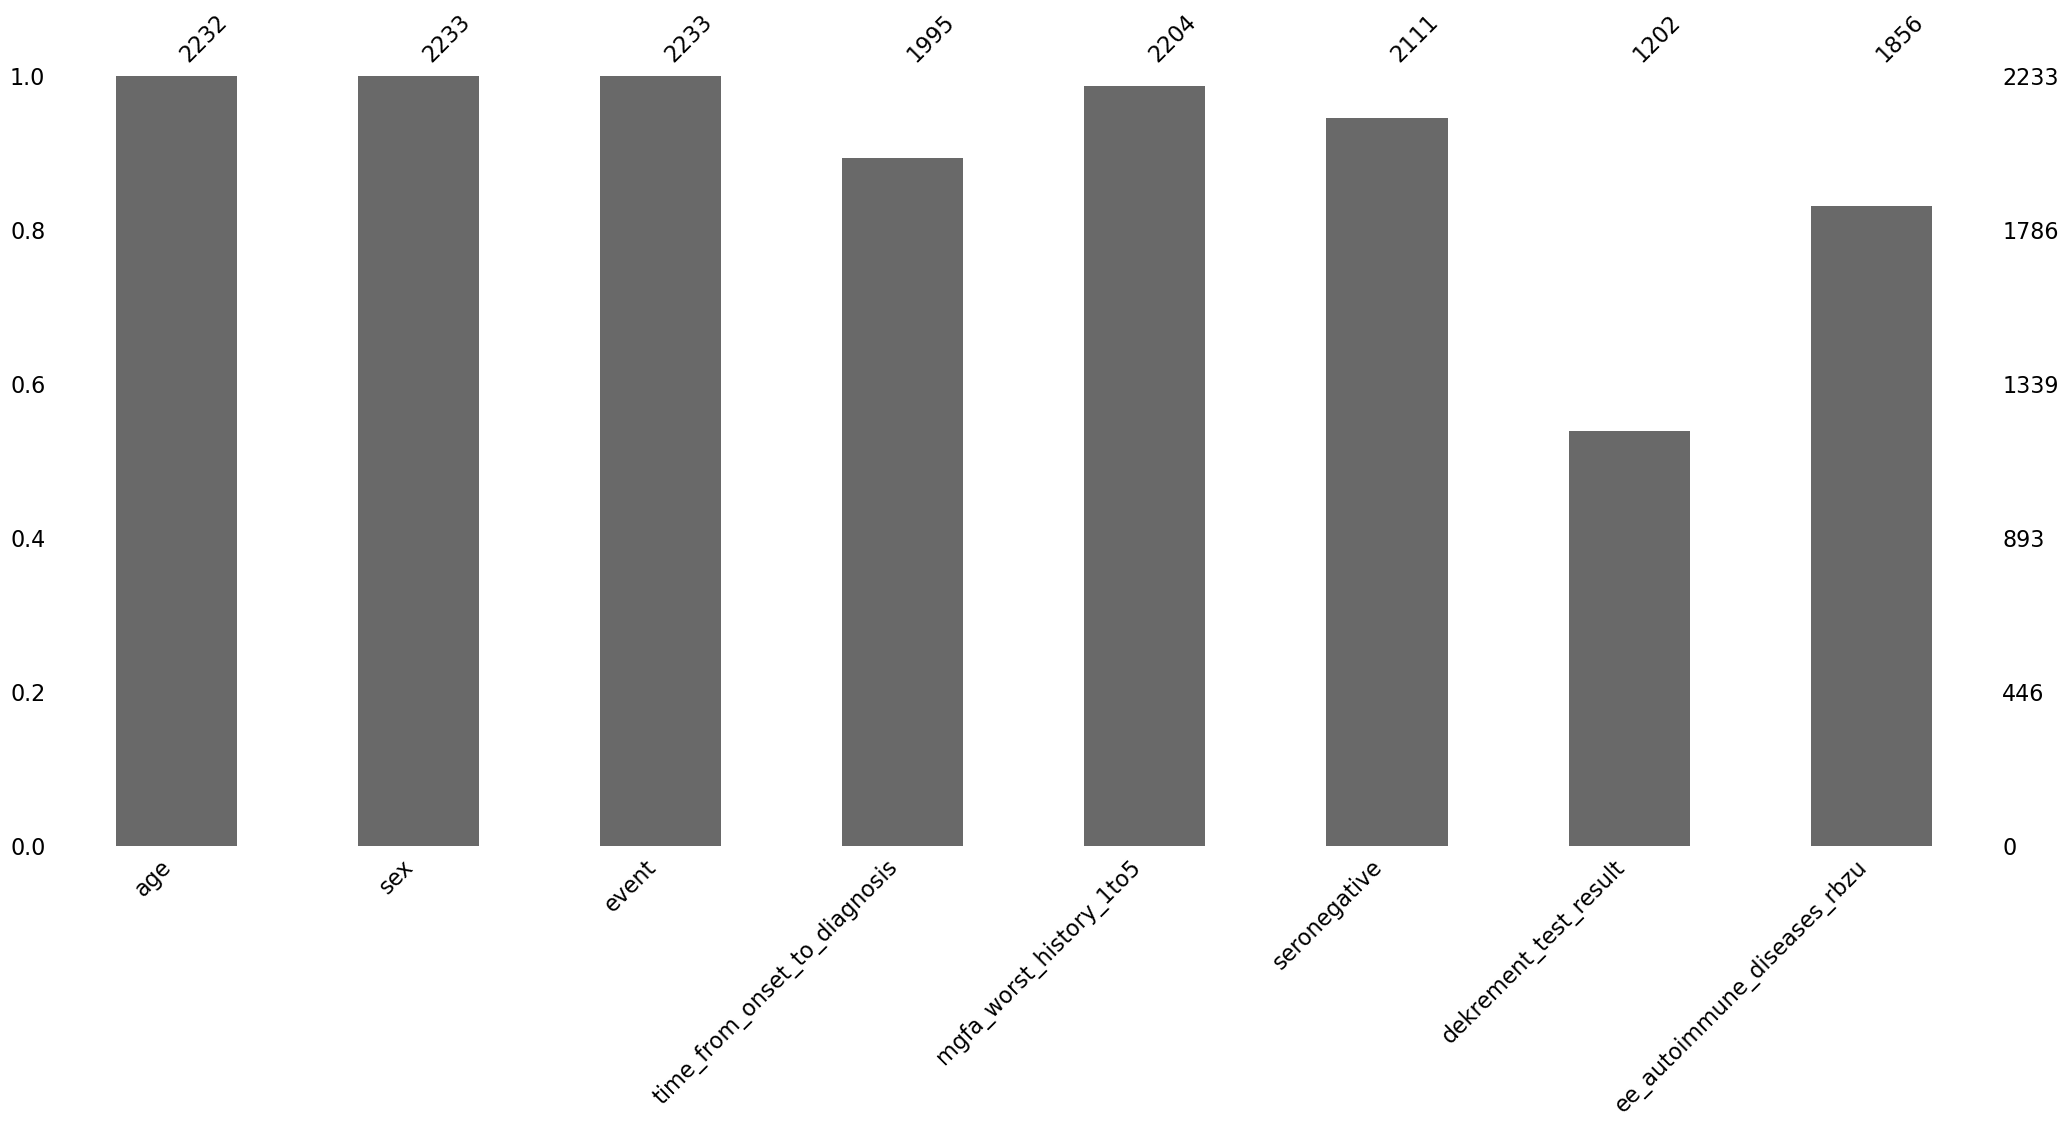

In [3]:
import missingno as msno 

msno.bar(df_original)

In [4]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor

# Define columns by type
continuous_columns = ['age', 'time_from_onset_to_diagnosis']
categorical_columns = ['seronegative', 'ee_autoimmune_diseases_rbzu', 'dekrement_test_result']
ordinal_columns = ['mgfa_worst_history_1to5']

# Custom rounding for categorical variables
def round_and_cast_categorical(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df[columns] = df[columns].round().astype(int)
    return df

# Round and clip ordinal variables within expected range
def round_and_clip_ordinal(df: pd.DataFrame, columns: list[str], min_val: int = 1, max_val: int = 5) -> pd.DataFrame:
    for col in columns:
        df[col] = df[col].round().clip(lower=min_val, upper=max_val).astype(int)
    return df

# Enforce non-negative constraint on continuous columns
def clip_non_negative_continuous(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df[columns] = df[columns].applymap(lambda x: max(x, 0))
    return df

In [5]:
# Configure estimator for imputer
dt_regressor = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=0
)

# Set up MICE-style imputer
mice_imputer = IterativeImputer(
    estimator=dt_regressor,
    max_iter=30,
    random_state=0,
    tol=1e-4,
    n_nearest_features=10,
    initial_strategy='median'
)

In [6]:
# Impute missing values
df_imputed_array = mice_imputer.fit_transform(df_original)
df_imputed = pd.DataFrame(df_imputed_array, columns=df_original.columns)

# Post-process imputed values
df_imputed = round_and_cast_categorical(df_imputed, categorical_columns)
df_imputed = round_and_clip_ordinal(df_imputed, ordinal_columns)
df_imputed = clip_non_negative_continuous(df_imputed, continuous_columns)

# Final imputed dataset
df_imputed_dataset = df_imputed
df_imputed_dataset.head()

,age,sex,event,time_from_onset_to_diagnosis,mgfa_worst_history_1to5,seronegative,dekrement_test_result,ee_autoimmune_diseases_rbzu
0,34.961111,0.0,1.0,0.166667,5,0,1,0
1,59.711111,1.0,1.0,3.166667,2,0,1,0
2,83.344444,1.0,1.0,0.250000,3,0,0,1
3,56.505556,1.0,1.0,0.083333,2,0,1,0
4,39.986111,0.0,1.0,0.000000,3,0,1,1


In [7]:
df_imputed_dataset.isnull().sum()

age                             0
sex                             0
event                           0
time_from_onset_to_diagnosis    0
mgfa_worst_history_1to5         0
seronegative                    0
dekrement_test_result           0
ee_autoimmune_diseases_rbzu     0
dtype: int64

<lifelines.CoxPHFitter: fitted with 2233 total observations, 0 right-censored observations>
             duration col = 'time_from_onset_to_diagnosis'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 2233
number of events observed = 2233
   partial log-likelihood = -14893.67
         time fit was run = 2025-12-17 06:25:26 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
age                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex                          0.38      1.47      0.05            0.29            0.48                1.34                1.61
mgfa_worst_history_1to5     -0.04      0.97      0.03           -0.09            0.02                0.92                1.02
seronegative                -0.37      0.69      0.05           -0.47           -0.27                0.62                0.76
dekrement_test_result        0.11      1.12      0.04            0.03            0.20                1.03                1.22
ee_autoimmune_diseases_rbzu -0.06      0.95      0.05           -0.15            0.04                0.86                1.04

                             cmp to     z      p  -log2(p)
covariate                                                 
age                            0.00  1.73   0.08      3.57
sex                            0.00  8.15 <0.005     51.25
mgfa_worst_history_1to5        0.00 -1.33   0.18      2.46
seronegative                   0.00 -7.09 <0.005     39.43
dekrement_test_result          0.00  2.58   0.01      6.65
ee_autoimmune_diseases_rbzu    0.00 -1.09   0.28      1.86
---
Concordance = 0.60
Partial AIC = 29799.34
log-likelihood ratio test = 193.98 on 6 df
-log2(p) of ll-ratio test = 127.70

<Axes: xlabel='log(HR) (95% CI)'>

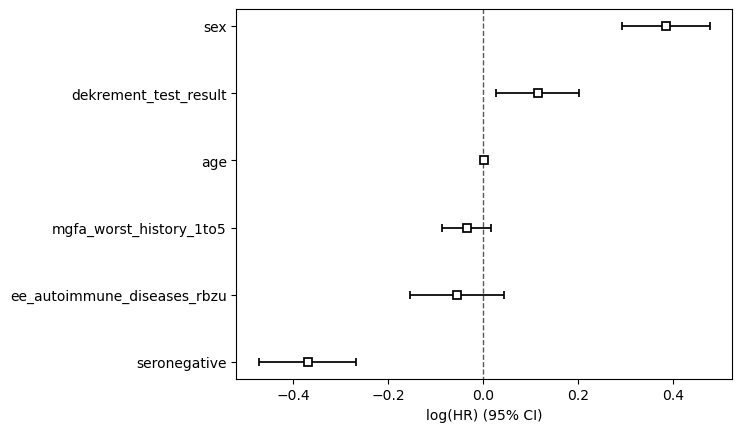

In [8]:
# Fit the Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(
    df_imputed_dataset,
    duration_col='time_from_onset_to_diagnosis',
    event_col='event'
)

# Show the summary results
cph.print_summary()

# Plot the coefficients (optional)
cph.plot()

In [9]:
from lifelines.statistics import proportional_hazard_test

# Perform proportional hazards test
results = proportional_hazard_test(cph, df_imputed_dataset, time_transform='rank')

results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 2233 total observations, 0 right-censored observations>
         test_name = proportional_hazard_test

---
                             test_statistic      p  -log2(p)
age                                   14.98 <0.005     13.17
dekrement_test_result                  2.03   0.15      2.70
ee_autoimmune_diseases_rbzu            0.00   0.95      0.08
mgfa_worst_history_1to5                0.13   0.72      0.48
seronegative                           6.03   0.01      6.15
sex                                    1.16   0.28      1.83

In [10]:
cph.check_assumptions(df_imputed_dataset, p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 2233 total observations, 0 right-censored observations>
         test_name = proportional_hazard_test

---
                                  test_statistic      p  -log2(p)
age                         km             13.87 <0.005     12.32
                            rank           14.98 <0.005     13.17
dekrement_test_result       km              1.38   0.24      2.06
                            rank            2.03   0.15      2.70
ee_autoimmune_diseases_rbzu km              0.01   0.93      0.10
                            rank            0.00   0.95      0.08
mgfa_worst_history_1to5     km              0.77   0.38      1.39
                            rank            0.13   0.72      0.48
seronegative                km              1.29   0.26      1.96
                            rank            6.03   0.01      6.15
sex                         km              1.61   0.20      2.29
                            rank            1.16   0.28      1.83



1. Variable 'age' failed the non-proportional test: p-value is 0.0001.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'seronegative' failed the non-proportional test: p-value is 0.0141.

   Advice: with so few unique values (only 2), you can include `strata=['seronegative', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readt

[]

In [11]:
cph.fit(
    df_imputed_dataset,
    duration_col='time_from_onset_to_diagnosis',
    event_col='event',
    strata=['seronegative']
)

<lifelines.CoxPHFitter: fitted with 2233 total observations, 0 right-censored observations>